# Cross-Event Analysis

This is the principal analytical notebook of the Delhi AQI / GRAP project. It
describes the **average behaviour** of pollution and weather around the nine
verified GRAP interventions, pooling across events and stations, and separately
checks how consistent that average behaviour is from one event to the next.

**This notebook is descriptive. It is not causal inference.** Every profile,
table, and figure below describes what the data looks like around a GRAP order
taking effect. None of it isolates GRAP's contribution from weather, season, or
any other factor moving over the same days -- the reasons why are restated in
Section 6 and were established in `docs/analysis_plan.md` before this notebook
was written.

> The notebook assumes it is run from the `notebooks/` folder, so the data path
> below starts with `../`. This notebook does not modify any earlier notebook.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# The event-window table built in 06_event_window_construction.ipynb --
# one row per event x station x relative day, +/-7 days around each event.
event_windows = pd.read_csv('../data/processed/event_windows_master.csv')

print('Rows:', len(event_windows))
print('Events:', event_windows['event_id'].nunique())
print('Stations:', event_windows['station_name'].nunique())
event_windows.head()

Rows: 1080
Events: 9
Stations: 8


,event_id,event_date,relative_day,calendar_date,station_name,pm25_ugm3,pm10_ugm3,air_temp_c,rh_pct,wind_speed_ms,wind_dir_deg,grap_stage,is_before_event,is_event_day,is_after_event
0,E001,2022-10-05,-7,2022-09-28,Anand Vihar,90.35,559.60,28.50,70.08,0.42,254.59,0,True,False,False
1,E001,2022-10-05,-6,2022-09-29,Anand Vihar,97.47,574.12,28.51,67.69,0.46,246.48,0,True,False,False
2,E001,2022-10-05,-5,2022-09-30,Anand Vihar,107.01,554.88,28.62,68.46,0.45,240.65,0,True,False,False
3,E001,2022-10-05,-4,2022-10-01,Anand Vihar,108.54,567.01,28.94,66.04,0.52,210.88,0,True,False,False
4,E001,2022-10-05,-3,2022-10-02,Anand Vihar,94.53,543.08,29.11,62.74,0.69,230.77,0,True,False,False


**What this does.** Loads the event-window table produced by the previous
notebook -- the shared input for every section below.

**Why this matters.** Every figure in this notebook pools rows across all nine
events and all eight stations at each relative day, unless a section explicitly
says otherwise (Section 4 breaks that pooling out per event on purpose). Loading
one table once keeps every section's arithmetic consistent with the others.

**How to read this.** Confirm the row count is 1,080 (9 events x 8 stations x 15
relative days) before continuing -- this is the same table validated in the
previous notebook.

# Section 1 -- Mean Event Profile: PM2.5

For every relative day from -7 to +7, we pool PM2.5 across all nine events and
all eight stations and compute the mean, median, standard deviation, and
observation count.

In [2]:
# Pool every event and station together at each relative day, and compute the
# four summary statistics requested for PM2.5.
pm25_profile = event_windows.groupby('relative_day')['pm25_ugm3'].agg(
    mean='mean', median='median', std='std', count='count'
).round(2)

pm25_profile

,mean,median,std,count
relative_day,,,,
-7,165.34,185.51,68.60,71
-6,180.06,195.01,80.14,71
-5,174.66,182.68,73.52,72
-4,184.12,189.14,68.58,72
-3,211.14,209.46,101.91,72
-2,189.53,189.49,85.59,72
-1,187.49,192.19,67.17,72
0,206.13,184.33,102.06,72
1,168.04,166.03,90.76,72


**What this does.** Groups every row in the table by `relative_day` (ignoring
which event or station a row came from) and computes the mean, median, standard
deviation, and count of PM2.5 within each relative day.

**Why this matters.** Pooling across events and stations is what produces a
single "average event" profile -- one line describing what a typical day at
relative position *d* looks like, across every event and every station that
contributed to it.

**How to read this.** `count` shows how many of the possible 72 station-events
(9 events x 8 stations) actually had a PM2.5 reading on that relative day; a
count below 72 means some rows were missing on that day.

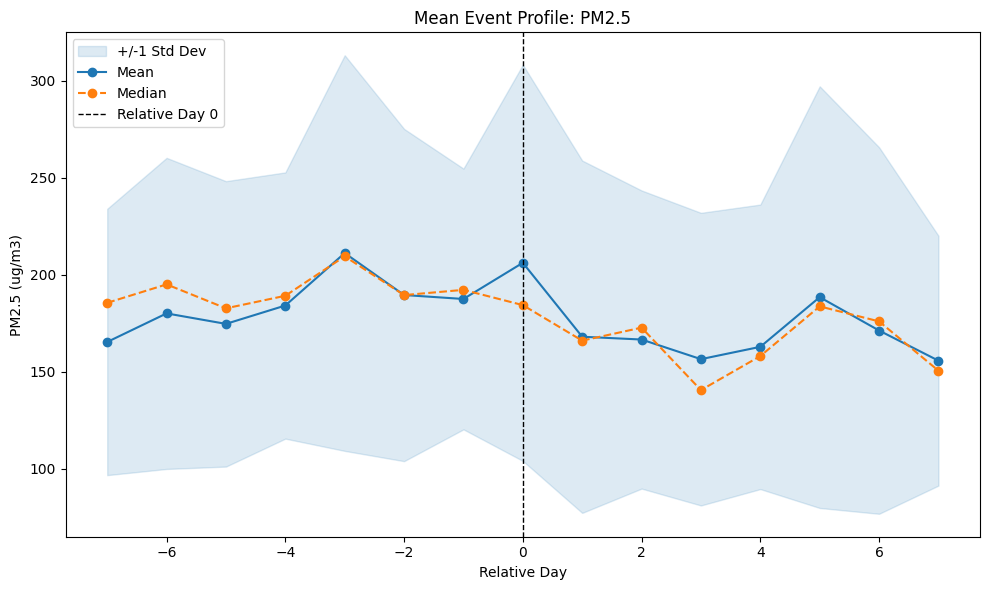

In [3]:
# Plot the mean line, the median line, and a shaded +/-1 standard deviation
# band around the mean, with a dashed vertical line marking the event day.
plt.figure(figsize=(10, 6))

plt.fill_between(
    pm25_profile.index,
    pm25_profile['mean'] - pm25_profile['std'],
    pm25_profile['mean'] + pm25_profile['std'],
    color='tab:blue', alpha=0.15, label='+/-1 Std Dev'
)
plt.plot(pm25_profile.index, pm25_profile['mean'], color='tab:blue', marker='o', label='Mean')
plt.plot(pm25_profile.index, pm25_profile['median'], color='tab:orange', marker='o', linestyle='--', label='Median')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1, label='Relative Day 0')

plt.title('Mean Event Profile: PM2.5')
plt.xlabel('Relative Day')
plt.ylabel('PM2.5 (ug/m3)')
plt.legend()
plt.tight_layout()
plt.show()

**What this does.** Plots the mean and median PM2.5 lines from the table above
against relative day, shades the region one standard deviation above and below
the mean, and marks relative day 0 with a dashed vertical line.

**Why this matters.** The mean and median together show whether the "typical"
day and the "average" day agree; the shaded band shows how much a single day's
reading can plausibly deviate from that average, at each point in the window.

**How to read this.** A wide shaded band means individual days vary a lot around
the mean at that relative day; a narrow band means days cluster tightly. The
dashed line is a position marker for the event day -- it does not by itself
indicate a change in either line.

# Section 2 -- Mean Event Profile: PM10

The same construction as Section 1, repeated for PM10.

In [4]:
pm10_profile = event_windows.groupby('relative_day')['pm10_ugm3'].agg(
    mean='mean', median='median', std='std', count='count'
).round(2)

pm10_profile

,mean,median,std,count
relative_day,,,,
-7,305.61,312.01,121.52,72
-6,321.18,321.49,138.67,72
-5,312.63,292.70,126.49,72
-4,324.96,308.04,121.15,72
-3,350.72,338.30,146.55,72
-2,333.32,313.74,136.84,72
-1,335.87,318.26,112.47,72
0,353.02,341.46,141.75,72
1,300.12,288.68,142.93,72


**What this does.** Repeats the Section 1 grouping and aggregation for PM10
instead of PM2.5.

**Why this matters.** Building the PM10 profile the same way as PM2.5 keeps the
two pollutants directly comparable, chart to chart and table to table.

**How to read this.** Read the `count` column the same way as in Section 1 --
as a check on how complete each relative day's pooled PM10 reading is.

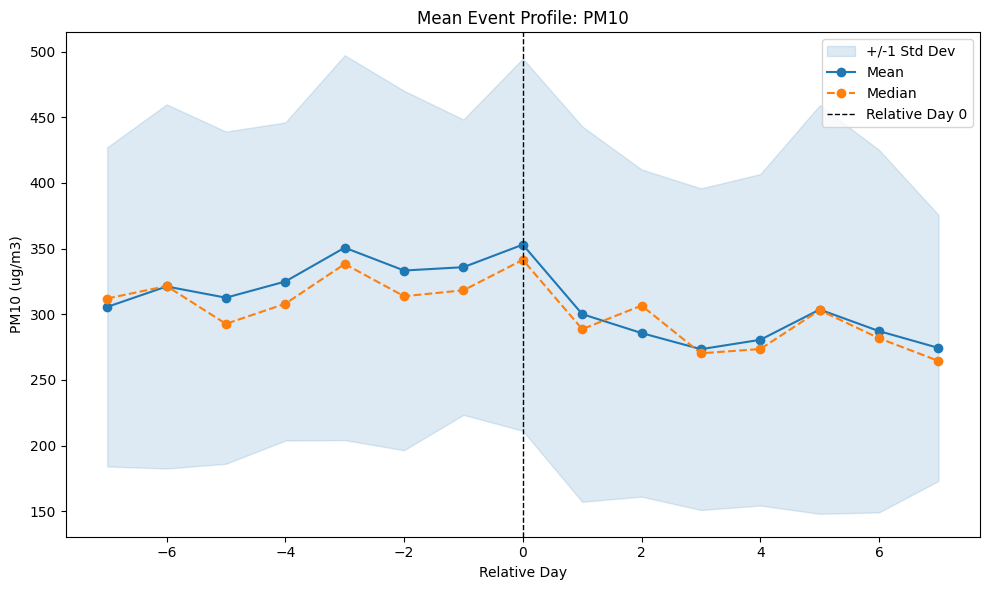

In [5]:
plt.figure(figsize=(10, 6))

plt.fill_between(
    pm10_profile.index,
    pm10_profile['mean'] - pm10_profile['std'],
    pm10_profile['mean'] + pm10_profile['std'],
    color='tab:blue', alpha=0.15, label='+/-1 Std Dev'
)
plt.plot(pm10_profile.index, pm10_profile['mean'], color='tab:blue', marker='o', label='Mean')
plt.plot(pm10_profile.index, pm10_profile['median'], color='tab:orange', marker='o', linestyle='--', label='Median')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1, label='Relative Day 0')

plt.title('Mean Event Profile: PM10')
plt.xlabel('Relative Day')
plt.ylabel('PM10 (ug/m3)')
plt.legend()
plt.tight_layout()
plt.show()

**What this does.** Draws the same mean/median/shaded-band chart as Section 1,
using the PM10 profile table above.

**Why this matters.** Having PM10 built and drawn identically to PM2.5 makes it
possible to place the two charts side by side and see whether the coarser
particulate fraction follows the same shape as PM2.5 across the window.

**How to read this.** Read this chart the same way as the PM2.5 chart in
Section 1, and compare the two shapes directly.

# Section 3 -- Weather Context

Pollution does not move in isolation. Before drawing any conclusion from the
pollutant profiles above, we build the same relative-day average profile for the
three weather variables available in this dataset: temperature, humidity, and
wind speed.

In [6]:
# Average profile (mean only) for each weather variable, pooled the same way
# as the pollutant profiles above.
weather_profile = event_windows.groupby('relative_day')[
    ['air_temp_c', 'rh_pct', 'wind_speed_ms']
].mean().round(2)

weather_profile

,air_temp_c,rh_pct,wind_speed_ms
relative_day,,,
-7,23.17,67.76,0.58
-6,22.67,67.39,0.59
-5,22.66,67.61,0.63
-4,22.88,69.03,0.68
-3,22.62,68.70,0.68
-2,22.65,66.28,0.69
-1,22.71,67.20,0.73
0,22.50,67.23,0.78
1,22.12,67.63,0.80


**What this does.** Groups the same table by relative day and computes the mean
of temperature, humidity, and wind speed at each relative day, pooled across all
events and stations exactly as the pollutant means were.

**Why this matters.** If a weather variable is also moving across the window --
gradually, or sharply at relative day 0 -- that movement is a plausible
alternative explanation for any change seen in the pollutant profiles, and needs
to be seen before the pollutant profiles are read any further.

**How to read this.** Compare the shape of each weather variable's movement
across the window to the shape of the PM2.5 and PM10 profiles above -- looking
for co-movement, not for proof of any particular cause.

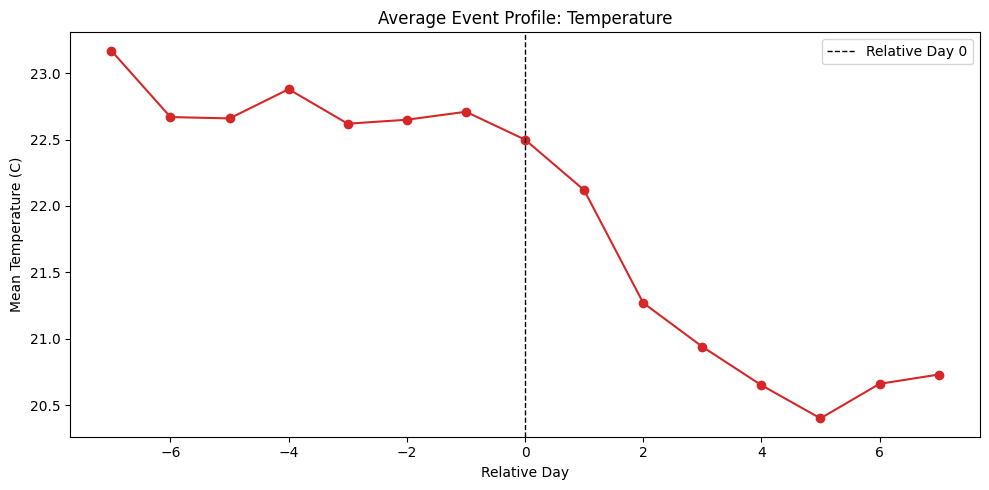

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(weather_profile.index, weather_profile['air_temp_c'], color='tab:red', marker='o')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1, label='Relative Day 0')
plt.title('Average Event Profile: Temperature')
plt.xlabel('Relative Day')
plt.ylabel('Mean Temperature (C)')
plt.legend()
plt.tight_layout()
plt.show()

**What this does.** Plots the mean temperature line from the table above against
relative day, with the same dashed vertical marker at relative day 0 used
throughout this notebook.

**Why this matters.** Temperature drives vertical mixing in the atmosphere, so
its own trajectory across the window is part of the context needed to read the
PM2.5 and PM10 profiles responsibly.

**How to read this.** Note whether the line moves gradually across the whole
window or shows any sharper change close to relative day 0.

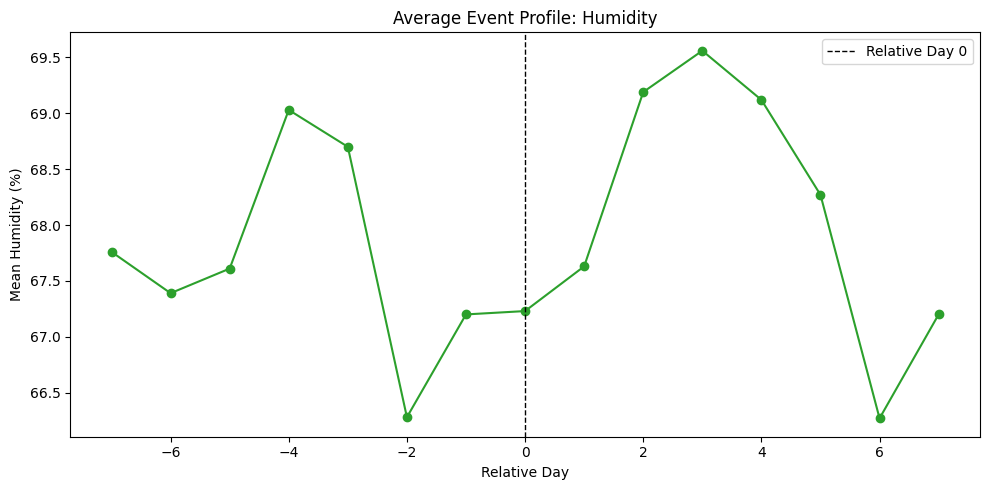

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(weather_profile.index, weather_profile['rh_pct'], color='tab:green', marker='o')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1, label='Relative Day 0')
plt.title('Average Event Profile: Humidity')
plt.xlabel('Relative Day')
plt.ylabel('Mean Humidity (%)')
plt.legend()
plt.tight_layout()
plt.show()

**What this does.** Plots the mean humidity line against relative day, the same
way as the temperature chart above.

**Why this matters.** Humidity is linked to particulate formation and settling,
so it is a second weather variable worth reading alongside the pollutant
profiles rather than in isolation.

**How to read this.** As with temperature, note the overall range the line moves
within and whether its movement is gradual or abrupt around relative day 0.

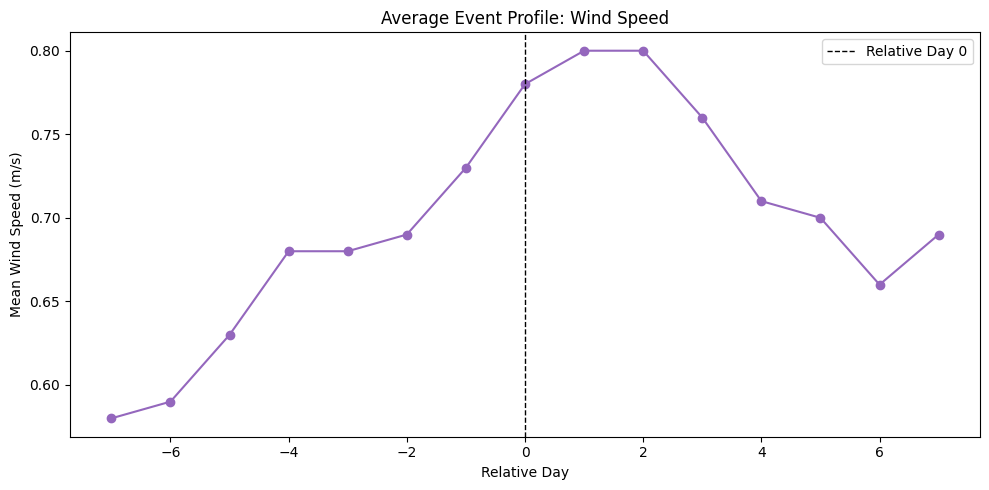

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(weather_profile.index, weather_profile['wind_speed_ms'], color='tab:purple', marker='o')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1, label='Relative Day 0')
plt.title('Average Event Profile: Wind Speed')
plt.xlabel('Relative Day')
plt.ylabel('Mean Wind Speed (m/s)')
plt.legend()
plt.tight_layout()
plt.show()

**What this does.** Plots the mean wind speed line against relative day, the
same way as the other two weather charts.

**Why this matters.** Wind speed is a primary mechanical driver of pollutant
dispersion, independent of any policy action, which is exactly why it is
documented in `docs/analysis_plan.md` as a confounding variable for this study.

**How to read this.** Compare this line's shape to the PM2.5 and PM10 profiles
in Sections 1 and 2 -- a period of rising wind speed alongside falling PM2.5 is
a pattern worth noting, not a demonstration of what caused what.

# Section 4 -- Event Consistency

Sections 1-3 pooled all nine events into a single average profile. Here we take
the profile apart again, event by event, to see how much the nine individual
events agree or disagree with that average and with each other.

In [10]:
# One PM2.5 profile per event: average across the 8 stations, per relative day,
# kept separate by event_id this time instead of pooled.
event_profiles = event_windows.groupby(['event_id', 'relative_day'])['pm25_ugm3'].mean()
event_profiles = event_profiles.unstack('event_id')

event_profiles.round(1)

event_id,E001,E002,E003,E004,E005,E006,E007,E008,E009
relative_day,,,,,,,,,
-7,55.8,66.6,124.1,197.0,223.1,200.4,191.1,219.1,214.0
-6,71.2,53.7,135.2,232.4,272.8,249.2,217.4,224.0,169.3
-5,84.4,72.1,177.4,240.5,248.9,109.8,248.5,213.9,176.3
-4,86.9,92.7,161.3,223.1,242.5,172.1,219.1,266.6,192.8
-3,73.6,114.3,145.8,272.8,407.9,231.6,224.0,259.1,171.1
-2,43.5,120.1,197.0,248.9,344.2,195.3,213.9,189.6,153.3
-1,64.7,119.4,232.4,242.5,200.6,168.0,266.6,193.5,199.7
0,93.2,112.1,240.5,407.9,174.7,152.3,259.1,134.1,281.3
1,17.6,117.4,223.1,344.2,200.4,108.7,189.6,152.7,158.7


**What this does.** Groups PM2.5 by event and relative day together, averages
across the 8 stations within each (event, day) pair, and reshapes the result so
each of the nine events becomes its own column.

**Why this matters.** This table is the per-event version of the pooled Section
1 table -- the same relative-day axis, but kept separate event by event so each
event's own shape can be seen before it is folded back into an average.

**How to read this.** Scan down each column to see one event's trajectory, and
across each row to see how much the nine events differ from each other on the
same relative day.

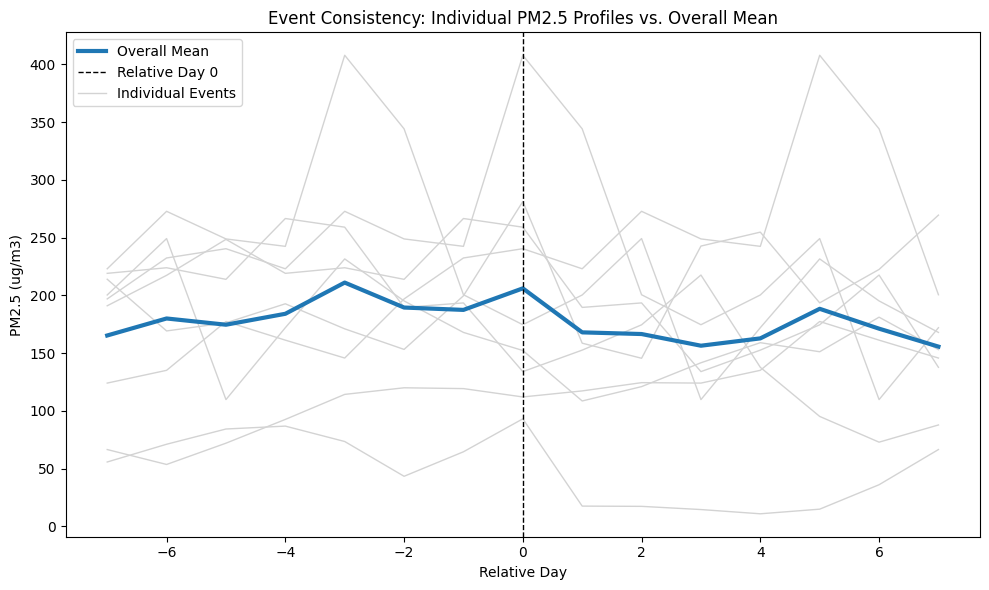

In [11]:
# Overlay every individual event's PM2.5 profile in light grey, then overlay
# the overall pooled mean profile (from Section 1) in bold blue on top.
plt.figure(figsize=(10, 6))

for event_id in event_profiles.columns:
    plt.plot(
        event_profiles.index, event_profiles[event_id],
        color='lightgrey', linewidth=1,
    )

plt.plot(
    pm25_profile.index, pm25_profile['mean'],
    color='tab:blue', linewidth=3, label='Overall Mean'
)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1, label='Relative Day 0')

# A single legend entry stands in for all nine grey lines.
plt.plot([], [], color='lightgrey', linewidth=1, label='Individual Events')

plt.title('Event Consistency: Individual PM2.5 Profiles vs. Overall Mean')
plt.xlabel('Relative Day')
plt.ylabel('PM2.5 (ug/m3)')
plt.legend()
plt.tight_layout()
plt.show()

**What this does.** Draws all nine per-event PM2.5 lines from the table above in
light grey on the same axes, then draws the pooled overall mean line from
Section 1 on top in bold blue.

**Why this matters.** This is the chart this section exists to produce: a direct
visual answer to whether the nine events look like variations on the same
underlying pattern, or whether they diverge enough that a single "average event"
line is a poor stand-in for any of them individually.

**How to read this.** Where the grey lines run close together and close to the
blue line, the events agree; where the grey lines spread out or cross each
other, the events disagree, and the blue mean line is describing an "average
event" that may not resemble any single real one closely.

In [12]:
# A simple numeric companion to the chart above: how far apart the nine events
# are from each other at each relative day (max minus min), and how each
# event's own mean PM2.5 changed from its pre-window to its post-window.
event_spread = (event_profiles.max(axis=1) - event_profiles.min(axis=1)).round(1)
event_spread.name = 'Spread Across Events (max - min)'
print('PM2.5 spread across the 9 events, by relative day:')
print(event_spread)

print()
event_windows_period = event_windows.copy()
event_windows_period['period'] = 'Post'
event_windows_period.loc[event_windows_period['relative_day'] < 0, 'period'] = 'Pre'
event_windows_period.loc[event_windows_period['relative_day'] == 0, 'period'] = 'Event'

per_event_period_mean = event_windows_period[event_windows_period['period'] != 'Event'].groupby(
    ['event_id', 'period']
)['pm25_ugm3'].mean().unstack('period').round(1)
per_event_period_mean['Post Minus Pre'] = per_event_period_mean['Post'] - per_event_period_mean['Pre']

print('Per-event mean PM2.5, pre-window vs. post-window:')
per_event_period_mean

PM2.5 spread across the 9 events, by relative day:
relative_day
-7    167.3
-6    219.1
-5    176.8
-4    179.7
-3    334.4
-2    300.8
-1    201.9
 0    314.7
 1    326.6
 2    255.4
 3    234.3
 4    243.8
 5    392.9
 6    308.1
 7    202.9
Name: Spread Across Events (max - min), dtype: float64

Per-event mean PM2.5, pre-window vs. post-window:


period,Post,Pre,Post Minus Pre
event_id,,,
E001,25.5,68.6,-43.1
E002,140.8,91.3,49.5
E003,277.2,167.6,109.6
E004,207.3,236.7,-29.4
E005,189.5,277.2,-87.7
E006,145.2,189.5,-44.3
E007,171.4,226.6,-55.2
E008,134.1,223.7,-89.6
E009,212.5,182.4,30.1


**What this does.** Computes, for each relative day, how far apart the highest
and lowest of the nine event-level means are (the spread shown as grey-line
scatter in the chart above, expressed as a number). Separately, it computes each
event's own mean PM2.5 in its pre-window (relative days -7 to -1) versus its
post-window (relative days +1 to +7), and the plain difference between the two.

**Why this matters.** The overlay chart shows agreement and disagreement
visually; this table gives the same idea in numbers -- both how wide the events
spread at a given relative day, and whether each event's own pre-to-post
movement points the same direction as the others.

**How to read this.** A large spread value means the nine events sit far apart
on that relative day. In the "Post Minus Pre" column, a negative number means
that event's mean PM2.5 was lower after its window than before it, and a
positive number means it was higher -- read this per event, not as a group
average, since that is exactly what Section 5 does next.

# Section 5 -- Pre / Event / Post Descriptive Table

We now collapse the window into three periods -- Pre (relative days -7 to -1),
Event (relative day 0), and Post (relative days +1 to +7) -- and report plain
descriptive statistics for PM2.5 and PM10 within each period, pooled across all
nine events and eight stations. No hypothesis test is performed; the table below
reports only means, medians, standard deviations, and counts.

In [13]:
# Label every row with its period, based on relative_day.
labelled_windows = event_windows.copy()
labelled_windows['period'] = 'Post'
labelled_windows.loc[labelled_windows['relative_day'] < 0, 'period'] = 'Pre'
labelled_windows.loc[labelled_windows['relative_day'] == 0, 'period'] = 'Event'

# Fix the row order to Pre, Event, Post rather than alphabetical.
period_order = ['Pre', 'Event', 'Post']

pm25_by_period = labelled_windows.groupby('period')['pm25_ugm3'].agg(
    mean='mean', median='median', std='std', count='count'
).round(2)
pm25_by_period = pm25_by_period.reindex(period_order)

pm10_by_period = labelled_windows.groupby('period')['pm10_ugm3'].agg(
    mean='mean', median='median', std='std', count='count'
).round(2)
pm10_by_period = pm10_by_period.reindex(period_order)

print('PM2.5 by period:')
display(pm25_by_period)

print('PM10 by period:')
display(pm10_by_period)

PM2.5 by period:


,mean,median,std,count
period,,,,
Pre,184.67,189.14,79.45,502
Event,206.13,184.33,102.06,72
Post,167.05,162.12,84.67,504


PM10 by period:


,mean,median,std,count
period,,,,
Pre,326.33,314.44,129.56,504
Event,353.02,341.46,141.75,72
Post,286.42,281.33,130.83,504


**What this does.** Labels every row as Pre, Event, or Post based on its
relative day, then computes the mean, median, standard deviation, and count of
PM2.5 and PM10 within each of the three periods, pooled across every event and
station.

**Why this matters.** Collapsing 15 relative days into three periods trades
day-by-day detail for a compact, easy-to-scan summary -- useful for a quick
comparison of before, during, and after, as long as the day-by-day profiles in
Sections 1 and 2 are not forgotten in the process.

**How to read this.** Compare the three periods' means and medians to each
other, and check the `count` column against the maximum possible (7 relative
days x 9 events x 8 stations = 504 for Pre and Post; 1 x 9 x 8 = 72 for Event)
to see how complete each period's figure is. No statistical test has been run
on these numbers -- they are reported as plain descriptive statistics only.

# Section 6 -- Methodological Notes

**Why these are descriptive summaries.** Every figure and table above is a mean,
median, standard deviation, count, or a plain difference between two such
summaries. None of them involves a control group, a randomized assignment of
GRAP stages, or a model that isolates GRAP's contribution from anything else
happening on the same days. A descriptive summary reports what the data looks
like; it does not, by itself, explain why the data looks that way.

**Why weather still matters.** Section 3 was placed deliberately between the
pollutant profiles (Sections 1-2) and the event-consistency and period tables
(Sections 4-5), because temperature, humidity, and wind speed are not
bystanders. All three are documented confounders in `docs/analysis_plan.md`:
they move for reasons unrelated to GRAP, and they are independently known to
affect how PM2.5 and PM10 disperse. Any movement seen in the pollutant profiles
is occurring on top of whatever movement the weather profiles show over the same
days, and the two cannot be told apart by inspection alone.

**Why causal conclusions cannot be drawn.** Beyond weather, `docs/analysis_plan.md`
documents several further reasons this design cannot isolate a GRAP effect:
every station experiences the same city-wide stage at the same time, so there is
no untreated comparison group; the nine events fall within a single GRAP season,
so seasonal drift cannot be separated from any before/after movement; several
event windows overlap with each other (documented and handled explicitly in
Section 4's per-event breakdown); and emission sources such as crop-residue
burning, festival-related combustion, and construction activity are not recorded
in this dataset at all. None of these factors are held constant or randomized
here, so nothing in this notebook supports a claim that GRAP caused any of the
patterns described in Section 7.

# Section 7 -- Findings

The statements below describe only what the figures and tables in Sections 1-5
show. They are written as observations, not explanations, and none of them
should be read as evidence that GRAP caused any pattern described.

**The average PM2.5 profile** pooled across all nine events sits at a mean of
about 185 ug/m3 in the pre-window (relative days -7 to -1) and about 167 ug/m3
in the post-window (relative days +1 to +7) -- a pooled decline of roughly 18
ug/m3. The relative-day-0 mean, at about 206 ug/m3, sits above both the pre- and
post-window means. **The median profile** shows a similar pattern (about 189
ug/m3 pre-window versus about 162 ug/m3 post-window), though the relative-day-0
median (about 184 ug/m3) sits much closer to the pre-window level than the
relative-day-0 mean does -- consistent with a small number of unusually high
station-days pulling the relative-day-0 mean upward relative to its median.

**PM10** follows the same pooled direction as PM2.5: a pre-window mean of about
326 ug/m3, a relative-day-0 mean of about 353 ug/m3, and a post-window mean of
about 286 ug/m3.

**The variability between events**, visualised in Section 4, is substantial. At
several relative days the spread between the highest and lowest of the nine
event-level means exceeds 300 ug/m3 -- larger than the pooled mean level itself
at that same relative day. The per-event pre-to-post comparison in Section 4
shows six of the nine events with a lower mean PM2.5 in their post-window than
in their pre-window, and three events with a higher mean PM2.5 in their
post-window; the size of the change also varies widely from one event to
another. The overlay chart in Section 4 shows the grey individual-event lines
spread widely around the bold blue mean line rather than tracking it closely,
which means the pooled average profile in Sections 1-2 describes a composite of
nine visibly different events rather than a pattern each event follows on its
own.

**Weather moved across the same window.** Mean temperature declined gradually
across the fifteen days (from about 23.2 C at relative day -7 to about 20.7 C at
relative day +7), without a sharp step at relative day 0. Mean humidity stayed
within a narrow band (roughly 66-70%) across the whole window. Mean wind speed
rose gradually from about 0.58 m/s at relative day -7 to a local high near
relative day +1/+2, before easing back down toward relative day +7 -- a change
that overlaps in time with the decline seen in the PM2.5 and PM10 post-window
means, though the two are only shown here as co-occurring patterns, not as a
demonstrated cause and effect.

**Missing data was minor at the pooled level.** Two of the 1,080 rows in the
event-window table are missing a PM2.5 reading (both in one event's pre-window,
at a single station); PM10 and the three weather variables are missing at most
one row each. This has negligible effect on the pooled counts reported in
Sections 1, 2, and 5.

# Section 8 -- Questions for Future Analysis

1. Does the six-versus-three split in per-event pre-to-post direction (Section
   4) correspond to any observable difference between those two groups of
   events -- for example, escalations versus de-escalations, or early-season
   versus late-season events?
2. The relative-day-0 PM2.5 mean sits above both the pre- and post-window means
   while the relative-day-0 median stays close to the pre-window level -- which
   specific station-days are driving that gap between the mean and the median?
3. Does narrowing or widening the event window (per the sensitivity checks
   planned in `docs/analysis_plan.md`) change the direction of the pre-to-post
   comparison for any of the three events that showed an increase?
4. Is the gradual rise in wind speed between relative day -7 and relative day
   +2 a pattern specific to these nine events, or does it also appear in
   non-event periods of the same months?
5. Do the events with the widest spread from the other events in Section 4
   (for example, around relative days -3, +1, and +5) share any common feature,
   such as overlapping windows or unusually high pre-window levels?
6. Would station-level profiles (rather than the city-average profiles used
   throughout this notebook) show the same six-versus-three pre-to-post split,
   or does that split vary by station?
7. How much of the pooled PM10 pattern is explained by PM2.5 alone, versus the
   coarser particulate fraction moving independently?
8. Does the pattern seen here for the 2022-23 GRAP season persist once a second
   season's verified events become available, as discussed under Future
   Improvements in `docs/analysis_plan.md`?

*End of the Cross-Event Analysis notebook.*